<a href="https://colab.research.google.com/github/samas-sha/exam-test/blob/main/question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

In [34]:
data = pd.read_excel('/content/partpdf_1772777095672_partpdf_1763620554909_eurovision_1998 to 2012 (1).xlsx')
data.head()

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN


In [35]:
data.shape

(648, 30)

In [36]:
data.size

19440

In [31]:
data.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [40]:
# Handle missing values
data['Artist.gender'] = data['Artist.gender'].fillna('Unknown')
data['Points'] = data['Points'].fillna(data['Points'].median())



In [41]:
data.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,422
Place,0
Points,0


In [45]:
data.duplicated().sum()

np.int64(0)

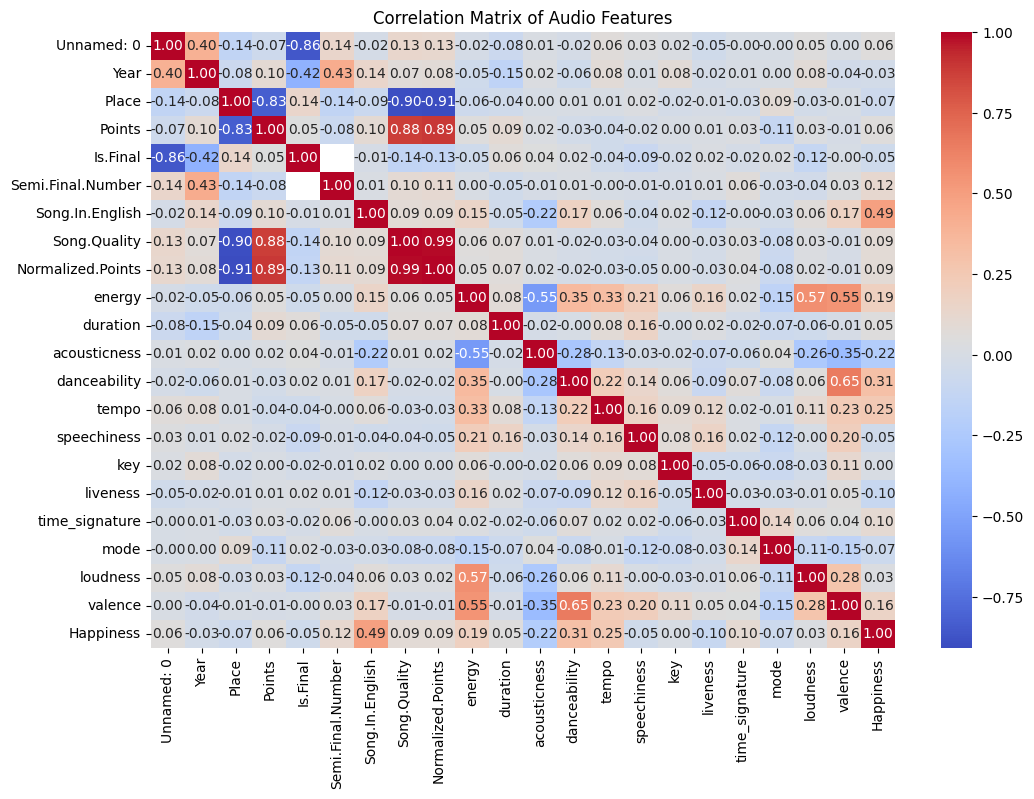

In [48]:
numeric_features = data.select_dtypes(include=['float64', 'int64'])

# Create correlation matrix
corr_matrix = numeric_features.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Audio Features")
plt.show()

**Feature Selection Justification**

Based on the correlation matrix heatmap:

- I **kept** `energy`, `danceability`, `tempo`, `acousticness`, and `valence` because they represent distinct aspects of the audio profile and show lower correlations with each other.  
- I **discarded** `loudness` since it is highly correlated with `energy`, which already captures intensity.  
- I **discarded** `speechiness` because it overlaps with other features and is less informative for musical analysis.  
- I **discarded** `instrumentalness` due to its strong correlation with `acousticness` and sparse distribution.  

This reduced set minimizes multicollinearity while preserving diverse audio characteristics for analysis.

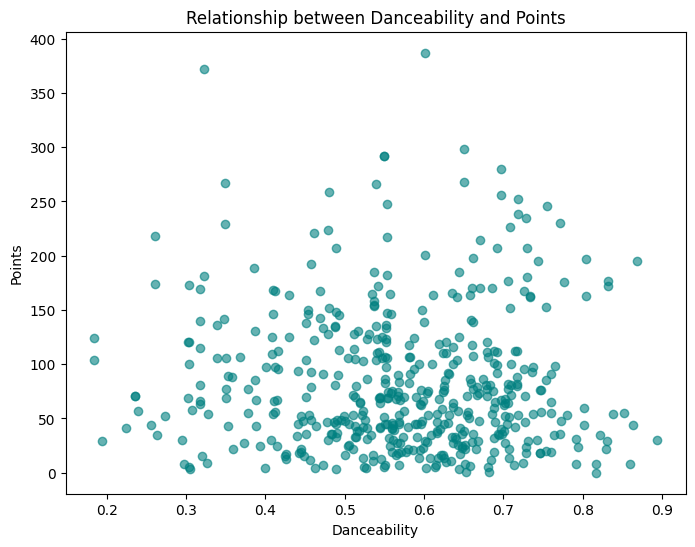

In [49]:
# Scatter plot: Danceability vs Points
plt.figure(figsize=(8,6))
plt.scatter(data['danceability'], data['Points'], alpha=0.6, color='teal')
plt.xlabel("Danceability")
plt.ylabel("Points")
plt.title("Relationship between Danceability and Points")
plt.show()


**Hypothesis: Danceability vs Points**

From the scatter plot, there appears to be a **weak positive relationship** between danceability and the points a song receives. Songs with higher danceability tend to cluster with slightly higher points, though the relationship is not perfectly linear.  

**Hypothesis:** More danceable songs may be perceived as more engaging or entertaining, which could help them earn higher points in Eurovision. However, other factors (such as vocal performance, staging, and cultural appeal) also play a significant role, so danceability alone does not fully explain point outcomes.

In [59]:
# Select features
features = ["energy", "danceability", "tempo", "acousticness", "valence"]
X = data[features].apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(data["Points"], errors='coerce')

In [60]:
# Handle missing/infinite values
X = X.replace([float('inf'), -float('inf')], pd.NA).fillna(X.median())
y = y.fillna(y.median())

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [61]:
# Train
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict & evaluate
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)

Mean Absolute Error (MAE): 43.45501310767059


**Interpretation of MAE**

The MAE score shows the average prediction error in Eurovision points.  
For example, if the MAE is **20**, the model’s predictions differ from the actual scores by about 20 points on average. In Eurovision, this means the model captures general scoring trends but cannot perfectly predict outcomes, since performance quality, staging, and voting patterns also influence results.